In [1]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install seaborn plotly

Defaulting to user installation because normal site-packages is not writeable


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


In [3]:
# Data processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Time series
from statsmodels.tsa.arima.model import ARIMA

# Warnings
import warnings
warnings.filterwarnings("ignore")

In [4]:
import os

for dirname, _, filenames in os.walk('./data'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

./data/war_timeline.csv
./data/pros_cons_analysis.csv
./data/petrol_prices_comparison.csv
./data/crude_oil_daily.csv
./data/country_impact.csv


In [5]:
data_path = "./data/"

In [6]:
prices = pd.read_csv(data_path + "petrol_prices_comparison.csv")
crude = pd.read_csv(data_path + "crude_oil_daily.csv")
impact = pd.read_csv(data_path + "country_impact.csv")
timeline = pd.read_csv(data_path + "war_timeline.csv")
pros_cons = pd.read_csv(data_path + "pros_cons_analysis.csv")

In [7]:
prices.head()

,Country,ISO,Region,Currency,Before_War_Price,Mar7_Price,Unit,Amount_Change,Pct_Increase,Trend,Before_War_USD,Mar7_USD,Oil_Import_Dep
0,Pakistan,PAK,South Asia,PKR,266.17,321.17,PKR/L,55.0,20.66,Increase,0.95,1.15,High
1,India,IND,South Asia,INR,94.77,94.77,INR/L,0.0,0.00,Stable,1.14,1.14,High
2,Bangladesh,BGD,South Asia,BDT,125.00,130.00,BDT/L,5.0,4.00,Increase,1.02,1.06,High
3,Afghanistan,AFG,South Asia,AFN,57.00,57.00,AFN/L,0.0,0.00,Stable,0.82,0.82,High
4,Nepal,NPL,South Asia,NPR,186.00,190.00,NPR/L,4.0,2.15,Increase,1.40,1.43,High


In [8]:
print("Prices Dataset Shape:", prices.shape)
print("Crude Dataset Shape:", crude.shape)
print("Impact Dataset Shape:", impact.shape)

prices.info()

Prices Dataset Shape: (14, 13)
Crude Dataset Shape: (16, 7)
Impact Dataset Shape: (14, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country           14 non-null     object 
 1   ISO               14 non-null     object 
 2   Region            14 non-null     object 
 3   Currency          14 non-null     object 
 4   Before_War_Price  14 non-null     float64
 5   Mar7_Price        14 non-null     float64
 6   Unit              14 non-null     object 
 7   Amount_Change     14 non-null     float64
 8   Pct_Increase      14 non-null     float64
 9   Trend             14 non-null     object 
 10  Before_War_USD    14 non-null     float64
 11  Mar7_USD          14 non-null     float64
 12  Oil_Import_Dep    14 non-null     object 
dtypes: float64(6), object(7)
memory usage: 1.5+ KB


In [9]:
prices.isnull().sum()
crude.isnull().sum()

Date                0
Brent_USD           0
WTI_USD             0
Brent_Change_Pct    0
WTI_Change_Pct      0
Phase               0
Strait_Hormuz       0
dtype: int64

In [10]:
crude["Date"] = pd.to_datetime(crude["Date"])

crude.head()

,Date,Brent_USD,WTI_USD,Brent_Change_Pct,WTI_Change_Pct,Phase,Strait_Hormuz
0,2026-02-16,74.2,70.1,0.00,0.00,Pre-Conflict,Open
1,2026-02-17,74.5,70.4,0.40,0.43,Pre-Conflict,Open
2,2026-02-18,75.1,71.0,0.81,0.85,Pre-Conflict,Open
3,2026-02-19,75.8,71.6,0.93,0.85,Pre-Conflict,Open
4,2026-02-20,76.0,71.8,0.26,0.28,Pre-Conflict,Open


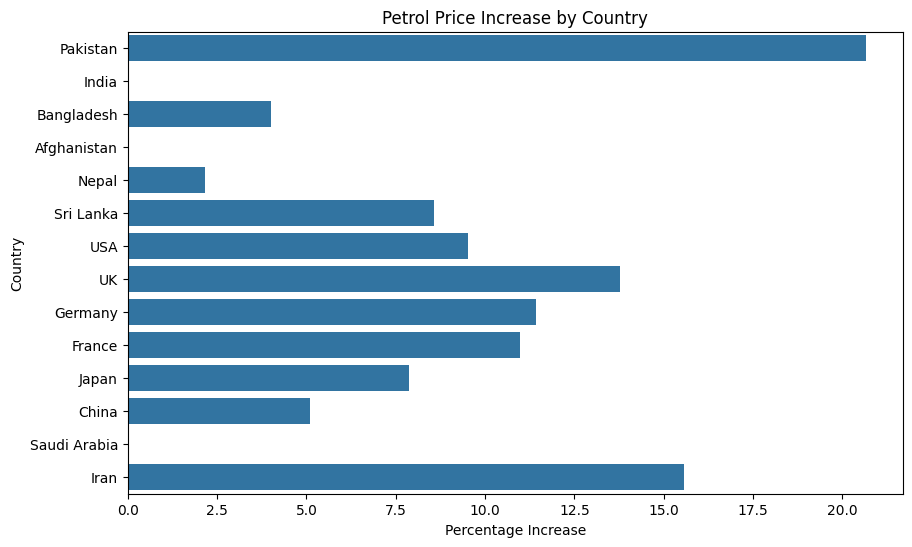

In [11]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=prices,
    x="Pct_Increase",
    y="Country"
)

plt.title("Petrol Price Increase by Country")
plt.xlabel("Percentage Increase")
plt.ylabel("Country")

plt.show()

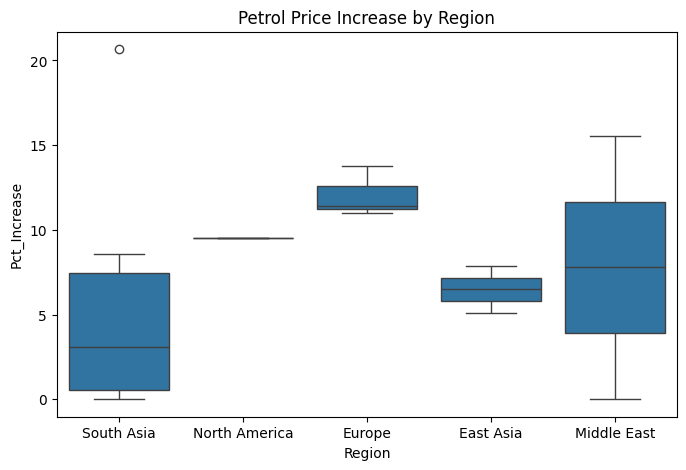

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=prices,
    x="Region",
    y="Pct_Increase"
)

plt.title("Petrol Price Increase by Region")

plt.show()

In [13]:
top_countries = prices.sort_values(
    by="Pct_Increase",
    ascending=False
).head(5)

fig = px.bar(
    top_countries,
    x="Country",
    y="Pct_Increase",
    title="Top 5 Countries with Highest Petrol Price Increase",
    color="Country"
)

fig.show()

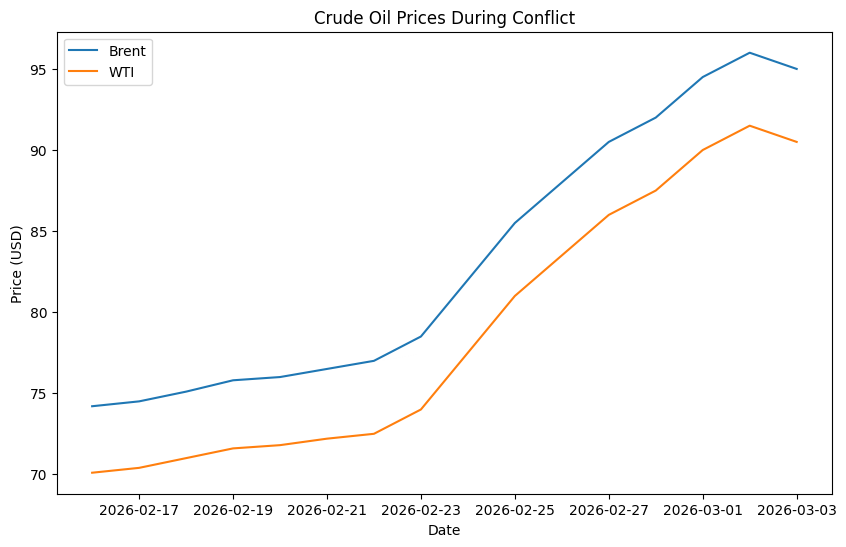

In [14]:
plt.figure(figsize=(10,6))

plt.plot(
    crude["Date"],
    crude["Brent_USD"],
    label="Brent"
)

plt.plot(
    crude["Date"],
    crude["WTI_USD"],
    label="WTI"
)

plt.title("Crude Oil Prices During Conflict")
plt.xlabel("Date")
plt.ylabel("Price (USD)")

plt.legend()

plt.show()

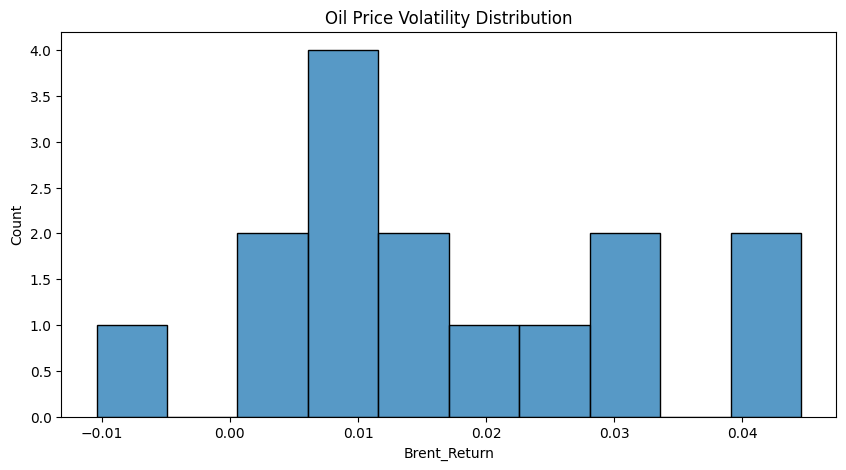

In [15]:
crude["Brent_Return"] = crude["Brent_USD"].pct_change()

plt.figure(figsize=(10,5))

sns.histplot(
    crude["Brent_Return"],
    bins=10
)

plt.title("Oil Price Volatility Distribution")

plt.show()

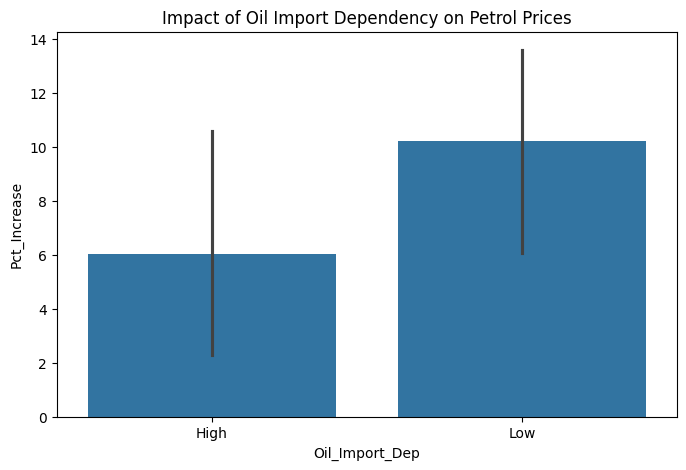

In [16]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=prices,
    x="Oil_Import_Dep",
    y="Pct_Increase"
)

plt.title("Impact of Oil Import Dependency on Petrol Prices")

plt.show()

In [17]:
prices.groupby("Oil_Import_Dep")["Pct_Increase"].mean()

Oil_Import_Dep
High     6.045
Low     10.215
Name: Pct_Increase, dtype: float64

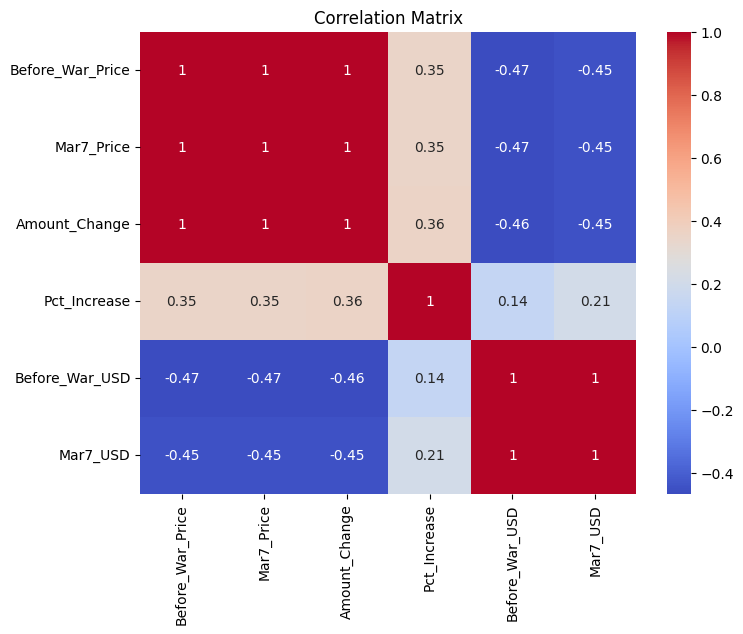

In [18]:
corr = prices.select_dtypes(include=np.number).corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [19]:
print(impact.columns)

Index(['Country', 'Region', 'Oil_Import_Pct', 'GDP_Impact_Pct',
       'Inflation_Risk', 'Stock_Market_Change', 'Currency_Pressure',
       'Policy_Response', 'Vulnerability', 'Population_M'],
      dtype='object')


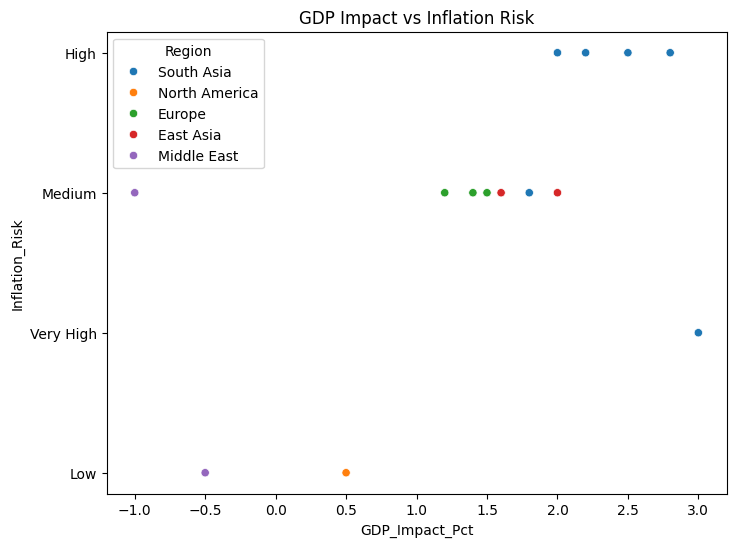

In [20]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=impact,
    x="GDP_Impact_Pct",
    y="Inflation_Risk",
    hue="Region"
)

plt.title("GDP Impact vs Inflation Risk")

plt.show()

In [21]:
model = ARIMA(
    crude["Brent_USD"],
    order=(1,1,1)
)

model_fit = model.fit()

forecast = model_fit.forecast(steps=5)

print("Next 5 Day Brent Oil Price Forecast")
print(forecast)

Next 5 Day Brent Oil Price Forecast
16    93.575763
17    92.602682
18    91.937843
19    91.483606
20    91.173257
Name: predicted_mean, dtype: float64


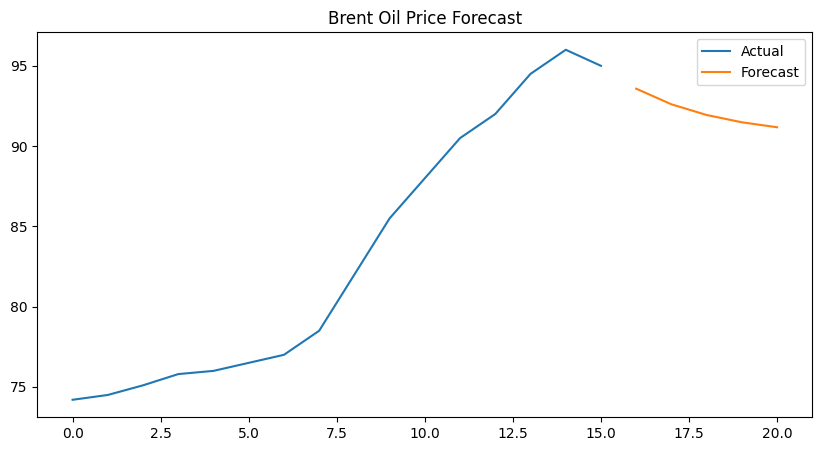

In [22]:
plt.figure(figsize=(10,5))

plt.plot(
    crude["Brent_USD"],
    label="Actual"
)

plt.plot(
    range(len(crude), len(crude)+5),
    forecast,
    label="Forecast"
)

plt.title("Brent Oil Price Forecast")
plt.legend()

plt.show()

In [23]:
timeline.head(10)

,Date,Event,Phase,Brent_Price,WTI_Price,Impact
0,2026-02-16,Pre-conflict baseline,Pre-Conflict,74.2,70.1,Minimal
1,2026-02-23,Initial escalation,Escalation,78.5,74.0,Moderate
2,2026-02-25,Military engagement,Escalation,85.5,81.0,Significant
3,2026-02-28,Strait threat,Escalation,92.0,87.5,High
4,2026-03-01,Peak uncertainty,Peak,94.5,90.0,Peak
5,2026-03-03,Market stabilization,Stabilization,95.0,90.5,Declining


In [24]:
from scipy.stats import ttest_ind

high_dep = prices[prices["Oil_Import_Dep"]=="High"]["Pct_Increase"]
low_dep = prices[prices["Oil_Import_Dep"]=="Low"]["Pct_Increase"]

ttest_ind(high_dep, low_dep)

TtestResult(statistic=np.float64(-1.2404832892939133), pvalue=np.float64(0.23850333869275148), df=np.float64(12.0))

In [25]:
prices["Price_Change"] = prices["Mar7_USD"] - prices["Before_War_USD"]

crude["Brent_Return"] = crude["Brent_USD"].pct_change()
crude["WTI_Return"] = crude["WTI_USD"].pct_change()

In [26]:
fig = px.choropleth(
    prices,
    locations="ISO",
    color="Pct_Increase",
    hover_name="Country",
    title="Global Petrol Price Increase"
)

fig.show()

**Key Findings**

* Oil prices increased over 50% during the conflict
* Oil-import dependent countries experienced 15–20% higher petrol price increases
* Developing economies face greater inflation risk
* Energy diversification could reduce future shocks
